# Classification

Compute the probability of GRB170817A (T = 2.0 s) of being a short GRB or a long GRB.

Decide a figure of merit and determine the threshold value for T90 to discriminate between short and long GRBs.

In [1]:
import matplotlib.pyplot as plt
import numpy as np

from mcmc_ensemble import thin_chains_by_acf
from mcmc import log_T90_distribution
from classification_probability import (classification_probability, 
                                        estimate_threshold, 
                                        estimate_threshold_distribution,
                                        distribution_probability_threshold)
%load_ext autoreload
%autoreload 2

In [2]:
FONTSIZE=16
LABELSIZE=0.9*FONTSIZE
LINEWIDTH=2.0
FIGWIDTH=8
ASPECT_RATIO=4/3

plt.rcParams['axes.labelsize'] = FONTSIZE
plt.rcParams['axes.linewidth'] = LINEWIDTH
plt.rcParams['axes.titlesize'] = 1.1*FONTSIZE
plt.rcParams['figure.figsize'] = [FIGWIDTH, FIGWIDTH/ASPECT_RATIO]
plt.rcParams['figure.labelsize'] = FONTSIZE
plt.rcParams['figure.titlesize'] = 1.1*FONTSIZE
plt.rcParams['legend.fancybox'] = False
plt.rcParams['legend.framealpha'] = 1.0
plt.rcParams['legend.fontsize'] = LABELSIZE
plt.rcParams['legend.title_fontsize'] = LABELSIZE
plt.rcParams['patch.linewidth'] = LINEWIDTH
plt.rcParams['lines.linewidth'] = LINEWIDTH
plt.rcParams['xtick.labelsize'] = LABELSIZE
plt.rcParams['ytick.labelsize'] = LABELSIZE
plt.rcParams['xtick.minor.visible'] = True
plt.rcParams['ytick.minor.visible'] = True
plt.rcParams['figure.autolayout'] = True

plt.rcParams['patch.edgecolor'] = 'black'

In [3]:
DATA_PATH = "../GRBs/GRB_data.txt"
arr = np.loadtxt(DATA_PATH, skiprows=1)
logT90       = arr[:,0]
sigma_logT90 = arr[:,1]

In [4]:
def gaussian_function(x, mu, sigma):
    return np.exp(-0.5*((x-mu)/sigma)**2)/(sigma*np.sqrt(2*np.pi))

def gaussian_mixture(x, w, mu1, mu2, sigma1, sigma2):
    return w*gaussian_function(x,mu1,sigma1) + (1-w)*gaussian_function(x,mu2,sigma2)

In [5]:
LOAD = 1

if LOAD == 0:
    # Esegue tutti i passagi per ottenere i samples dell'ensamble con dati reali e sigma_logT90
    data = np.load("../chains/chains_stack_real_sigmaT90_10.npz")
    chains  = data['chains']       # array 3D (n_chains,n_steps,5)
    
    chains_cut = chains.copy()
    chains_cut = np.delete(chains_cut, [3,4], axis=0)
    print(chains_cut.shape)
    
    burnin = 1000
    chains_new = chains_cut[:,burnin:,:]
    print(chains_new.shape)
    
    thinned_list, per_param_lags, per_chain_lags = thin_chains_by_acf(
        chains_new, threshold=0.0, max_lag_search=2000
    )
    for i in range(chains_new.shape[0]):
        print(f'chain {i+1} shape = {thinned_list[i].shape}')
    
    samples = np.concatenate([c for c in thinned_list], axis=0)  # shape (N_total, d)
    np.savetxt('../chains/chain_final.txt', samples)
else:
    samples = np.loadtxt('../chains/chain_final.txt')
print(samples.shape)

(4349, 5)


In [30]:
# Visto che è stato eseguito il thinning il valore di N corrisponde a N_ess
from mcmc import ess

DEFAULT_PARAM_LABELS = [
    'w',
    r'$\mu_1$',
    r'$\delta = \mu_2 - \mu_1$',
    r'$ln(\sigma_1)$',
    r'$ln(\sigma_2)$',
]

for i, label in enumerate(DEFAULT_PARAM_LABELS):
    print(f'N_ESS ({label}) = {ess(samples[:,i]):.0f}')

N_ESS (w) = 4349
N_ESS ($\mu_1$) = 4349
N_ESS ($\delta = \mu_2 - \mu_1$) = 4349
N_ESS ($ln(\sigma_1)$) = 4349
N_ESS ($ln(\sigma_2)$) = 4349


## Classificazione grafica con threshold

### Parametri medi

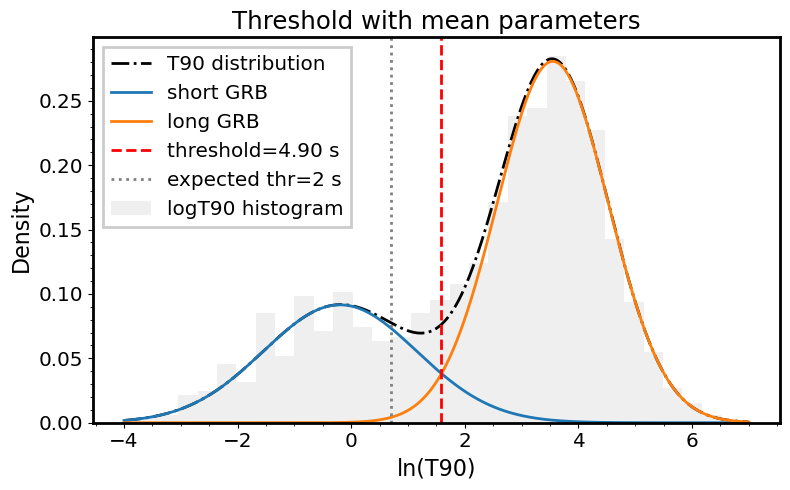

In [25]:
plt.figure(figsize=(8,5))
x = np.linspace(-4,7,10000)
plt.plot(x, gaussian_mixture(x, 0.310, -0.197, 3.549, 1.351, 0.981), linestyle='-.', color='k', label='T90 distribution')
plt.plot(x, 0.310*gaussian_function(x, -0.197, 1.351), label='short GRB')
plt.plot(x, (1-0.310)*gaussian_function(x, 3.549, 0.981), label='long GRB')       

condition = 0.310*gaussian_function(x, -0.197, 1.351) - (1-0.310)*gaussian_function(x, 3.549, 0.981)
thr_index = np.where(condition<=0)[0][0]
thr = x[thr_index]
plt.axvline(thr, linestyle='--', color='r', label=f"threshold={np.exp(thr):.2f} s", linewidth=2)
plt.axvline(np.log(2), linestyle=':', color='grey', label=f"expected thr=2 s", linewidth=2)

plt.hist(logT90, bins=30, density=True, alpha=0.35,
    facecolor='lightgrey', edgecolor='none', label='logT90 histogram', zorder=0)

plt.xlabel('ln(T90)')
plt.ylabel('Density')
plt.title('Threshold with mean parameters')
plt.legend()
plt.savefig('../figure/classification/threshold_mean_param.png', dpi=300)
plt.savefig('../figure/classification/threshold_mean_param.pdf', dpi=300)
plt.show()

### Modello mediano

Il modello mediano NON corrisponde al modello dei parametri mediani

In [6]:
x = np.linspace(-4,7,10001)

# log(T90) distribution
distribution_models = np.vstack([
        np.exp(log_T90_distribution(x, samples[i, :]))
        for i in range(samples.shape[0])
        ]) # shape -> (n_samples, n_points)
    

p_low, p_med, p_high = np.percentile(distribution_models, (5, 50, 95), axis=0)

# Short GRB
distribution_models_short = np.vstack([
        samples[i, 0]*gaussian_function(x, samples[i, 1], np.exp(samples[i, 3]))
        for i in range(samples.shape[0])
        ]) # shape -> (n_samples, n_points)
    
p_low_short, p_med_short, p_high_short = np.percentile(distribution_models_short, (5, 50, 95), axis=0)

# Long GRB
distribution_models_long = np.vstack([
        (1-samples[i, 0])*gaussian_function(x, samples[i, 1] + samples[i,2], np.exp(samples[i, 4]))
        for i in range(samples.shape[0])
        ]) # shape -> (n_samples, n_points)
    
p_low_long, p_med_long, p_high_long = np.percentile(distribution_models_long, (5, 50, 95), axis=0)

In [7]:
condition = p_med_short - p_med_long
thr_index = np.where(condition<=0)[0][0]
thr_med   = x[thr_index]
print(thr_med)

condition_right = p_low_short - p_high_long
thr_index_right = np.where(condition_right<=0)[0][0]
thr_right       = x[thr_index_right]

condition_left = p_high_short - p_low_long
thr_index_left = np.where(condition_left<=0)[0][0]
thr_left       = x[thr_index_left]
print(f"[{thr_left}, {thr_right}]")

1.5847000000000007
[1.8113000000000001, 1.3658000000000001]


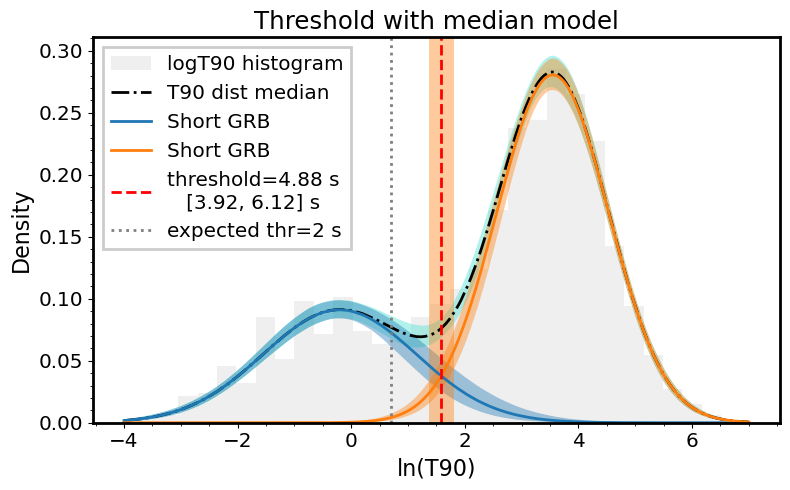

In [41]:
fig2, ax2 = plt.subplots(figsize=(8,5))

# background histogram of observations
ax2.hist(logT90, bins=30, density=True, alpha=0.35,
facecolor='lightgrey', edgecolor='none', label='logT90 histogram', zorder=0)

# log(T90) distribution
ax2.fill_between(x, p_low, p_high, alpha=0.4,
facecolor='turquoise', zorder=1)

ax2.plot(x, p_med, 'k-.', label=f'T90 dist median', zorder=2)

# Short GRB
ax2.fill_between(x, p_low_short, p_high_short, alpha=0.4,
facecolor='C0', zorder=1)

ax2.plot(x, p_med_short, 'C0-', label=f'Short GRB', zorder=2)

# Long GRB
ax2.fill_between(x, p_low_long, p_high_long, alpha=0.4,
facecolor='C1', zorder=1)

ax2.plot(x, p_med_long, 'C1-', label=f'Short GRB', zorder=2)

plt.axvspan(thr_right, thr_left, alpha=0.4, facecolor='C1', zorder=1)
plt.axvline(thr_med, linestyle='--', color='r', label=f"threshold={np.exp(thr_med):.2f} s\n   [{np.exp(thr_right):.2f}, {np.exp(thr_left):.2f}] s", linewidth=2)
plt.axvline(np.log(2), linestyle=':', color='grey', label=f"expected thr=2 s", linewidth=2)

""" Non funziona
dp_med      = p_med[1:] - p_med[:-1]
# Prendo solo i valori tra i massimi delle due gaussiane (unico punto stazionario rimanente è il minimo locale)
dp_med      = dp_med[np.argmax(p_med_short):np.argmax(p_med_long)]
k           = np.argmin(np.abs(dp_med)) + np.argmax(p_med_short)
thr_min_loc = (x[k] + x[k+1])/2.0
plt.axvline(thr_min_loc, linestyle=(0, (7, 7)), color='C2', label=f"thr local min={np.exp(thr_min_loc):.2f} s", linewidth=2)
"""

plt.xlabel('ln(T90)')
plt.ylabel('Density')
plt.title('Threshold with median model')
plt.legend()
plt.savefig('../figure/classification/threshold_median_model.png', dpi=300)
plt.savefig('../figure/classification/threshold_median_model.pdf', dpi=300)
plt.show()

## Classificazione con probabilità

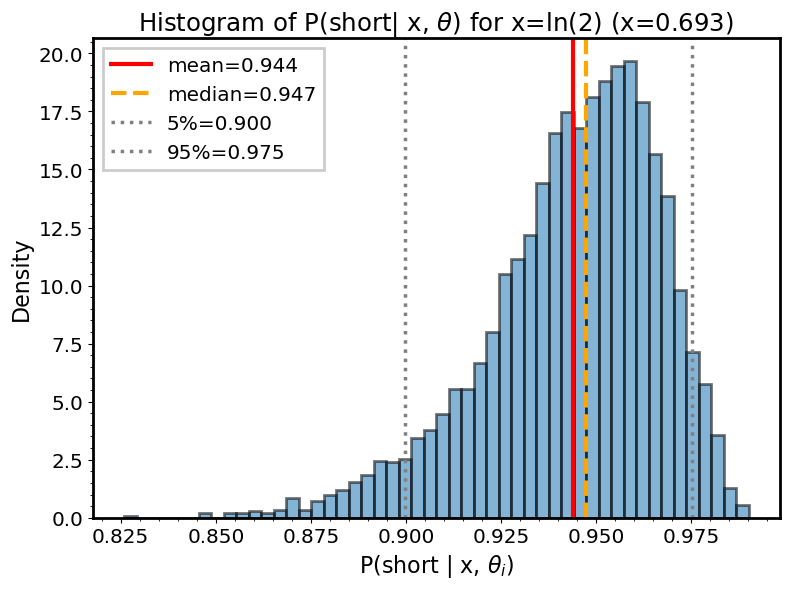

In [8]:
h = classification_probability(np.log(2), samples, model='short')

Indice più vicino: 1464
Valore: 0.6876319998718351 +- 0.3368526897938663


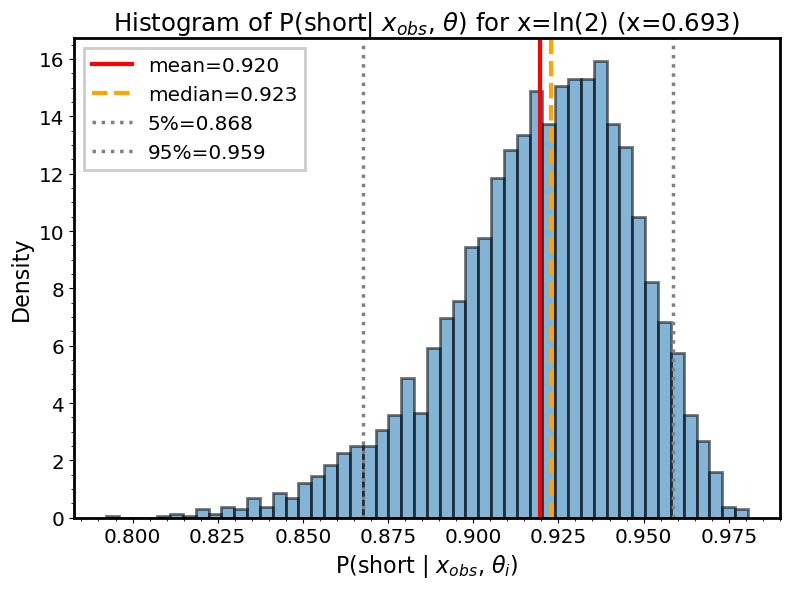

In [9]:
# Prendo valore disponibile più vicino a T90=2s (GRB170817A), in modo da stimare l'errore sigma_logT90
target = np.log(2)

# trova indice dell'elemento più vicino
idx = np.argmin(np.abs(logT90 - target))
print("Indice più vicino:", idx)
print(f"Valore: {logT90[idx]} +- {sigma_logT90[idx]}")

h = classification_probability(np.log(2), samples, sigma_logT90=sigma_logT90[idx], model='short')

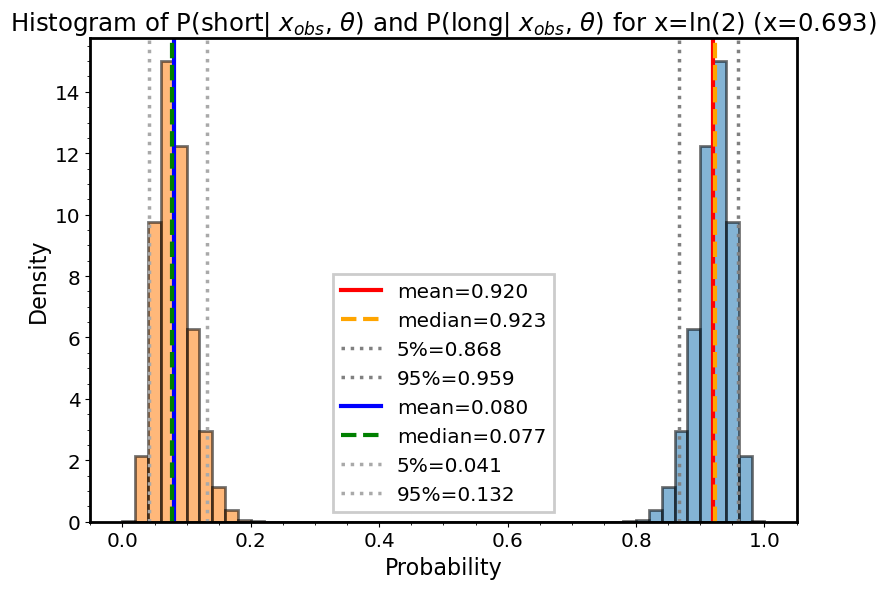

In [10]:
h_g = classification_probability(np.log(2), samples, sigma_logT90=sigma_logT90[idx], model='both')

### Probability of threshold estimated with grafic

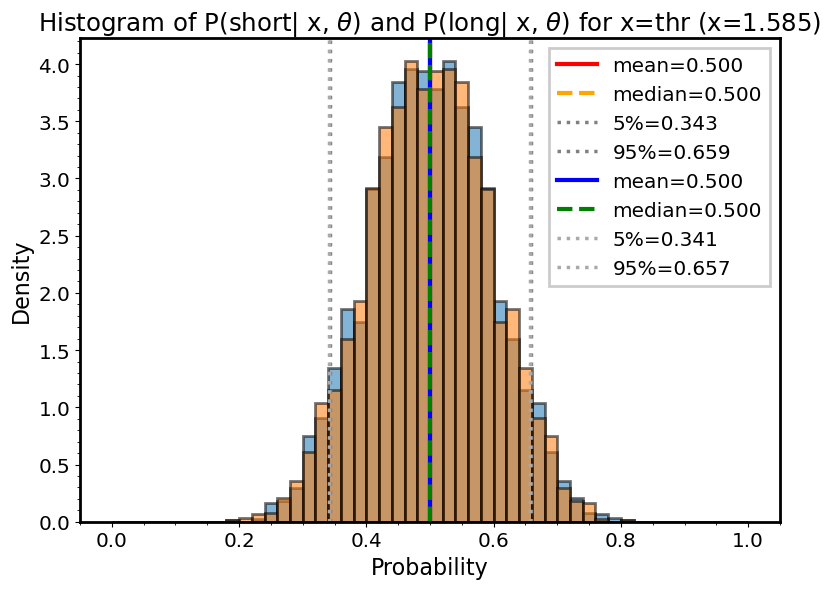

In [11]:
# Valore threshold ricavato con la mediana dei modelli nel metodo grafico
thr = 1.5847
h = classification_probability(thr, samples, name='thr', model='both')

Dai grafici si possono vedere due cose:
- La threshold attesa a 2s non è una buona soglia visto che le distribuzioni di probabilità di short e long sono ben separate con un probabilità media di essere short di 0.92 (con errore sulle x) e 0.94 (senza errore sulle x). Mentre la soglia trovata nel metodo grafico ha la media e mediana coincidenti con probabilità 0.5, quindi è una miglire stima.
- Anche se la soglia trovata nel metodo grafico è una migliore stima rispetto a 2s rimane il problema che il valore non è ben definito, infatti la distribuzione di probabilità è molto larga: da 0.34 a 0.66. Quindi il metodo migliore per classificare è estrarre la distribuzione di P(short| x, $\theta$) e vederre se l'intervallo di confidenza non è compatibile con 0.5: se sta sopra è short, se sta sotto è long. Nel caso fosse compatibile posso guardare se la mediana è sopra o sotto 0.5, ma devo tenere conto che posso effeture dei missclassification dovuti ad una probabilità non trascurabile di avere le due classificazioni.

### Probability threshold estimated with mean h

In [74]:
thr_mean_h = estimate_threshold(samples)

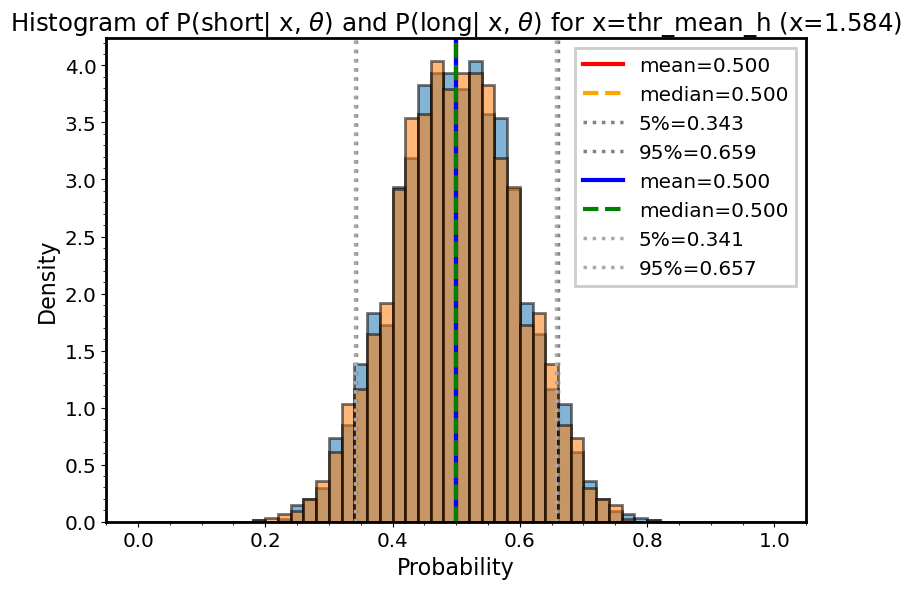

In [75]:
# Valore threshold ricavato con la mediana dei modelli nel metodo grafico
h = classification_probability(thr_mean_h, samples, name='thr_mean_h', model='both')

### Probability of threshold estimated threshold distribution

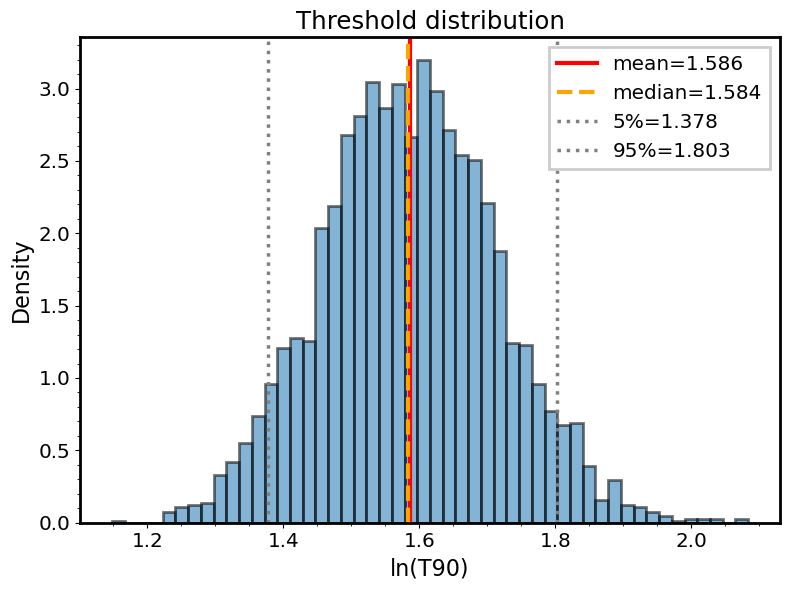

{'median': 1.5840274412042556, 'mean': 1.5861094625674732, 'std': 0.12830132346692197, '[5,95]%': [1.3775022453290462, 1.8030547196332638]}


In [76]:
thr_arr, info = estimate_threshold_distribution(samples)
print(info)

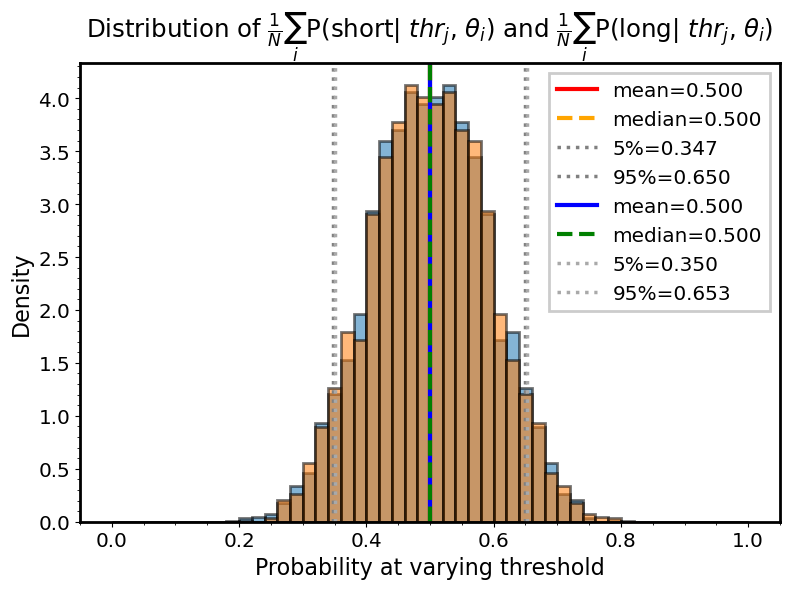

In [77]:
distribution_probability_threshold(samples,thr_arr)